In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from utils import plot_hist_per_columns, plot_scatter_per_columns, plot_box_per_columns, shapiro_wilk_test, outliers_detection, jarque_bera_test, QQPlot, log_transform

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [228]:
train_data = "../data/train.csv"
test_data = "../data/test.csv"
df_train = pd.read_csv(train_data)

In [229]:
missing_perc = df_train.isna().mean() * 100
missing_selected = missing_perc[missing_perc > 40]

missing_selected = missing_selected.apply(lambda x: "% " + str(round(x, 2)))

if (missing_perc > 0).any():
    print(missing_selected)
else:
    print("No missing values")

print()

if (df_train.duplicated().any()):
    print("Data has duplicated values.")
else:
    print("Data has no duplicated values.")

data_to_delete = missing_selected[missing_selected > "% 60"].index
data_to_delete

Alley          % 93.77
MasVnrType     % 59.73
FireplaceQu    % 47.26
PoolQC         % 99.52
Fence          % 80.75
MiscFeature     % 96.3
dtype: object

Data has no duplicated values.


Index(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [230]:
df_train_cat = df_train.select_dtypes(include=['object'])
try:
    df_train_cat_dummies = pd.get_dummies(df_train_cat, drop_first=True)
    for col in df_train_cat_dummies.columns:
        df_train_cat_dummies[col] = df_train_cat_dummies[col].astype(int)
except:
    pass

df_train_num = df_train.select_dtypes(include=['float64', 'int64'])

df_train = pd.concat([df_train_num, df_train_cat_dummies], axis=1)
df_train.index = df_train.pop('Id')


In [231]:
df_train['SalePrice'] = log_transform(df_train['SalePrice'])

In [232]:
corr = df_train.corr()['SalePrice'].sort_values(ascending=False).drop('SalePrice')
corr_abs = corr.abs().sort_values(ascending=False)
corr_abs_selected = corr_abs[corr_abs > 0.5]
corr_abs_selected

OverallQual        0.81718
GrLivArea          0.70093
GarageCars         0.68062
GarageArea         0.65089
TotalBsmtSF        0.61213
1stFlrSF           0.59698
ExterQual_TA       0.59588
FullBath           0.59477
YearBuilt          0.58657
YearRemodAdd       0.56561
GarageYrBlt        0.54107
KitchenQual_TA     0.53824
TotRmsAbvGrd       0.53442
Foundation_PConc   0.53084
ExterQual_Gd       0.50967
Name: SalePrice, dtype: float64

In [233]:
for col in corr_abs_selected.index:
    outliers_vals = outliers_detection(df_train[col])
    if outliers_vals:
        mask = df_train[col].isin(outliers_vals)
        df_train.loc[mask, col] = df_train[col].median()

sp_outliers = outliers_detection(df_train['SalePrice'])
if sp_outliers:
    sp_mask = df_train['SalePrice'].isin(sp_outliers)
    df_train.loc[sp_mask, 'SalePrice'] = df_train['SalePrice'].median()

print("Outliers encontrados y tratados con la mediana.")

Outliers encontrados y tratados con la mediana.


In [234]:
X = df_train[corr_abs_selected.index].fillna(df_train[corr_abs_selected.index].mean())
y = df_train["SalePrice"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     454.4
Date:                Fri, 22 Aug 2025   Prob (F-statistic):               0.00
Time:                        21:38:52   Log-Likelihood:                 541.78
No. Observations:                1460   AIC:                            -1052.
Df Residuals:                    1444   BIC:                            -967.0
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.7855      0.713  

In [235]:
columnas_significativas = model.pvalues < 0.05 
columnas_significativas = columnas_significativas[columnas_significativas].index
columnas_significativas = columnas_significativas.drop('const')

In [241]:
np.random.seed(18)

X = df_train.drop('SalePrice', axis=1).fillna(df_train.mean())
y = df_train['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

print("Mean squared error: %.5f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: % 5f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.5f" % r2_score(y_test, y_pred))

Mean squared error: 0.01244
Root mean squared error:  0.111522
Coefficient of determination: 0.91685


### Cross - Validation

In [242]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 10))
ridge.fit(X_train, y_train)
ridge.alpha_

y_pred = ridge.predict(X_test)

print("Mean squared error: %.5f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: % 5f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.5f" % r2_score(y_test, y_pred))

Mean squared error: 0.01124
Root mean squared error:  0.106042
Coefficient of determination: 0.92482


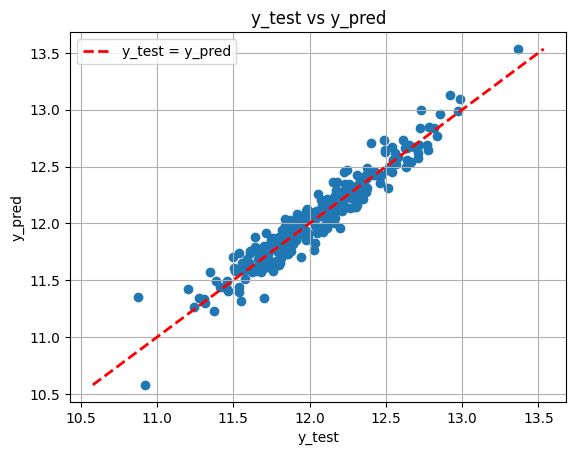

In [258]:
plt.scatter(y_pred, y_test) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y_test = y_pred')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs y_pred')
plt.grid()
plt.legend()
plt.show()

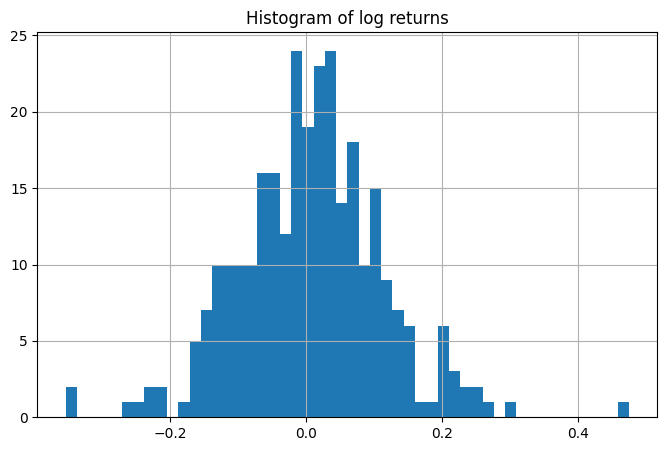

In [244]:
log_returns = pd.DataFrame(columns=['log_returns'], index= y_test.index)
log_returns['log_returns'] = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(log_returns, bins=50)
plt.title('Histogram of log returns')
plt.grid(1)
plt.show()

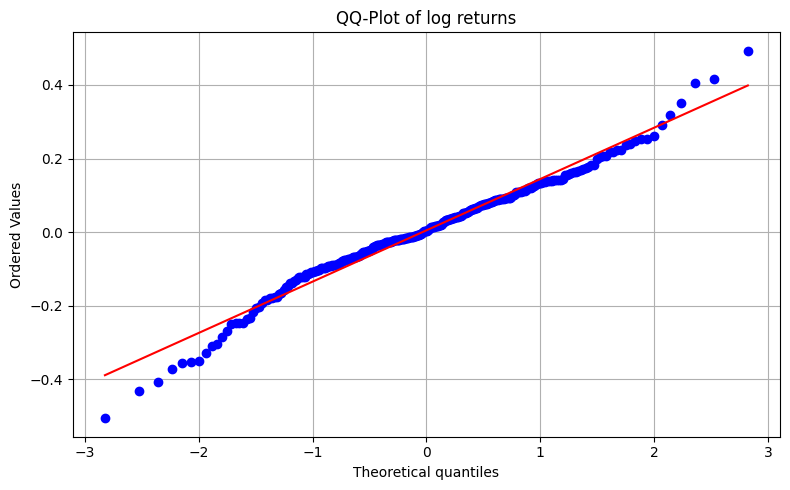

In [239]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

serie = np.asarray(log_returns).ravel()
serie = serie[~np.isnan(serie)]

plt.figure(figsize=(8,5))
stats.probplot(serie, dist='norm', plot=plt)
plt.grid(True)
plt.title('QQ-Plot of log returns')
plt.tight_layout()
plt.show()

# Submission

In [260]:
df_submission = pd.read_csv(test_data, index_col='Id')